### Medidas de Correlação com Python

#### Objetivos:
- Entender como calcular correlações entre variáveis.
- Aprender a usar o **Coeficiente de Correlação de Pearson** (para variáveis normalmente distribuídas).
- Explorar métodos não paramétricos como **Spearman** e **Kendall** (para variáveis que não seguem uma distribuição normal).
- Fazer uso de gráficos de correlação para melhor visualização dos dados.

#### Dataset
Vamos usar o dataset **`tips`** da biblioteca `seaborn`, que contém dados sobre gorjetas em um restaurante. Esse dataset é ótimo para explorar a relação entre variáveis como o total da conta e o valor da gorjeta.

### 1. Importando Bibliotecas e Carregando o Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, shapiro

#### Carregando o dataset tips
A base de dados contém informações de gorjetas em um restaurante, com dados sobre total da conta, sexo, fumo, dia, horário e tamanho do grupo.

In [2]:
df = sns.load_dataset('tips')

Exibindo as primeiras linhas do dataset

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Analisando variáveis numéricas

In [4]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [5]:
numericas = df.select_dtypes(include='number')
numericas.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Visualizações para entender as relações**

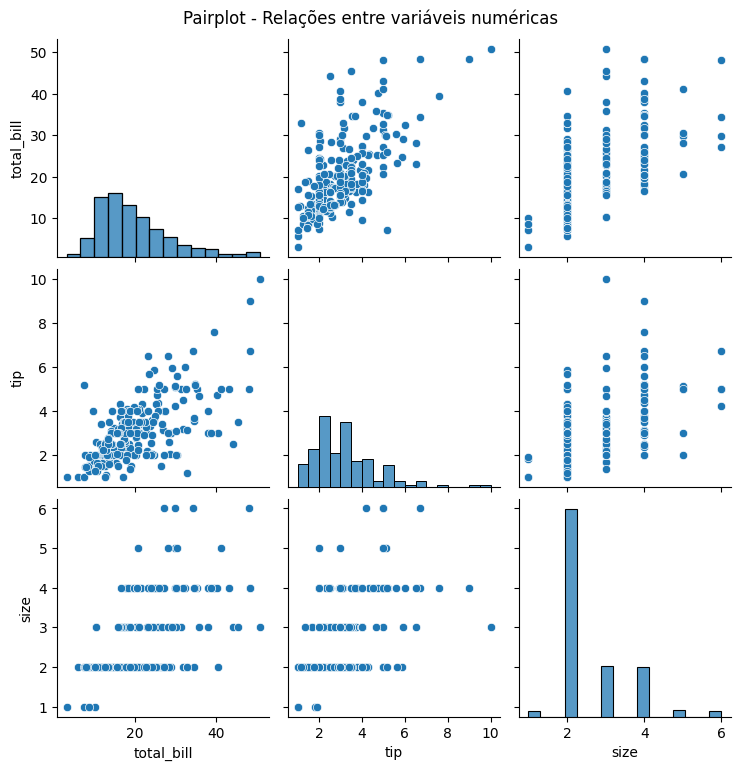

In [6]:
sns.pairplot(numericas)
plt.suptitle("Pairplot - Relações entre variáveis numéricas", y=1.02)
plt.show()

Testes de normalidade (Shapiro-Wilk)

In [7]:
print("\nTeste de normalidade (Shapiro-Wilk):")
for col in numericas.columns:
    stat, p = shapiro(numericas[col])
    print(f"{col}: stat={stat:.4f}, p={p:.4f}")


Teste de normalidade (Shapiro-Wilk):
total_bill: stat=0.9197, p=0.0000
tip: stat=0.8978, p=0.0000
size: stat=0.7120, p=0.0000


Como o valor de p < 0.05 indica que rejeitamos a hipótese nula, ou seja, os dados não possuem distribuição normal.

### 2. Correlação de Pearson

#### 2.1 O que é o Coeficiente de Correlação de Pearson?
O **Coeficiente de Correlação de Pearson** mede a **força** e a **direção** da relação linear entre duas variáveis quantitativas. Ele assume que as variáveis têm uma distribuição normal.

- **Quando usar**: Pearson é utilizado quando as variáveis têm uma relação linear e ambas seguem uma **distribuição normal**.

Onde \( r \) varia entre -1 e 1:
  - \( r = 1 \): Correlação positiva perfeita
  - \( r = -1 \): Correlação negativa perfeita
  - \( r = 0 \): Sem correlação linear

#### 2.2 Cálculo de Pearson
Vamos calcular a correlação de Pearson entre `total_bill` (valor total da conta) e `tip` (gorjeta).

#### Calculando a correlação de Pearson entre 'total_bill' e 'tip'

In [8]:
pearson_corr = df['total_bill'].corr(df['tip'], method='pearson')
print("Correlação de Pearson entre 'total_bill' e 'tip':", pearson_corr)

Correlação de Pearson entre 'total_bill' e 'tip': 0.6757341092113645


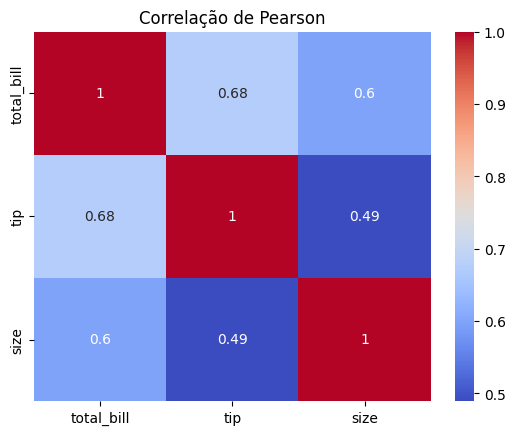

In [9]:
corr_pearson = numericas.corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Correlação de Pearson")
plt.show()

In [10]:
corr_pearson

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


### 3. Métodos Não Paramétricos: Spearman e Kendall

#### 3.1 Correlação de Spearman
O **Coeficiente de Spearman** mede a relação **monotônica** entre duas variáveis, o que significa que, à medida que uma variável aumenta, a outra também aumenta ou diminui, mas não necessariamente de forma linear.

- **Quando usar**: Use Spearman quando os dados não forem normalmente distribuídos ou se a relação entre as variáveis for **monotônica** (não linear).
- Baseia-se no ranking das variáveis.


#### 3.2 Cálculo de Spearman

#### Calculando a correlação de Spearman entre 'total_bill' e 'tip'

In [11]:
spearman_corr = df['total_bill'].corr(df['tip'], method='spearman')
print("Correlação de Spearman entre 'total_bill' e 'tip':", spearman_corr)

Correlação de Spearman entre 'total_bill' e 'tip': 0.6789681219001009


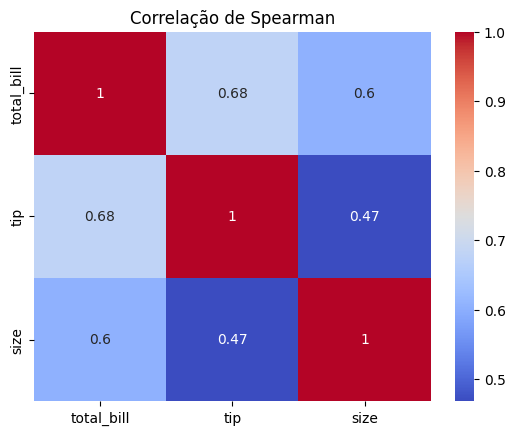

In [12]:
corr_spearman = numericas.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm")
plt.title("Correlação de Spearman")
plt.show()

#### 3.3 Correlação de Kendall
O **Coeficiente de Kendall** é outra medida não paramétrica que mede a associação entre duas variáveis. Ele leva em consideração a concordância entre pares de observações.

- **Quando usar**: Utilize Kendall quando o número de dados é pequeno, ou quando há muitos empates nos dados.
- Baseia-se na concordância e discordância de pares ordenados.


#### 3.4 Cálculo de Kendall

#### Calculando a correlação de Kendall entre 'total_bill' e 'tip'

In [13]:
kendall_corr = df['total_bill'].corr(df['tip'], method='kendall')
print("Correlação de Kendall entre 'total_bill' e 'tip':", kendall_corr)

Correlação de Kendall entre 'total_bill' e 'tip': 0.517180972142381


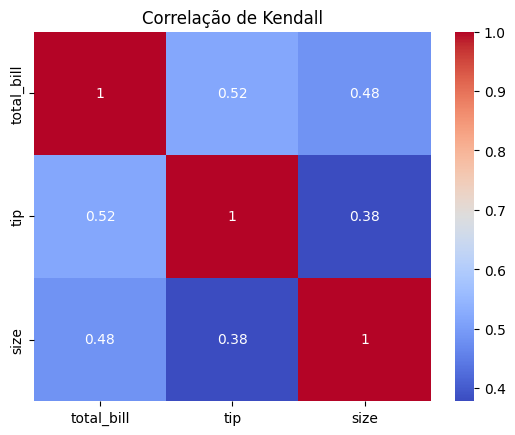

In [14]:
corr_kendall = numericas.corr(method='kendall')
sns.heatmap(corr_kendall, annot=True, cmap="coolwarm")
plt.title("Correlação de Kendall")
plt.show()

### 4. # Teste de Hipótese para Correlação entre total_bill e tip

- H0: rho = 0 (sem correlação)
- H1: rho ≠ 0

In [15]:
print("\nTeste de Hipótese - Correlação entre total_bill e tip")

r, p_valor = pearsonr(df['total_bill'], df['tip'])
print(f"Pearson r = {r:.4f}, p = {p_valor:.4f}")

r, p_valor = spearmanr(df['total_bill'], df['tip'])
print(f"Spearman r = {r:.4f}, p = {p_valor:.4f}")

r, p_valor = kendalltau(df['total_bill'], df['tip'])
print(f"Kendall tau = {r:.4f}, p = {p_valor:.4f}")


Teste de Hipótese - Correlação entre total_bill e tip
Pearson r = 0.6757, p = 0.0000
Spearman r = 0.6790, p = 0.0000
Kendall tau = 0.5172, p = 0.0000


Quando temos p-valor < 0,05 podemos dizer que temos uma Correlação significativa. 

### 5. Comparando os Métodos
- **Pearson**: Usado quando as variáveis são normalmente distribuídas e têm uma relação linear.
- **Spearman**: Adequado quando as variáveis têm uma relação monotônica, mas não necessariamente linear, ou quando os dados não seguem uma distribuição normal.
- **Kendall**: Preferido em datasets pequenos ou com muitos empates, fornecendo uma medida mais robusta em alguns casos.


### 6. 📌 Análise com dataset Iris
Explorando a correlação entre atributos das flores (Iris Dataset)

In [16]:
iris = sns.load_dataset("iris")

Exibindo as primeiras linhas do dataset

In [17]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Explorando a base de dados

In [18]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [20]:
iris_numericas = iris.select_dtypes(include='number')

Visualização para entender a relação dos dados

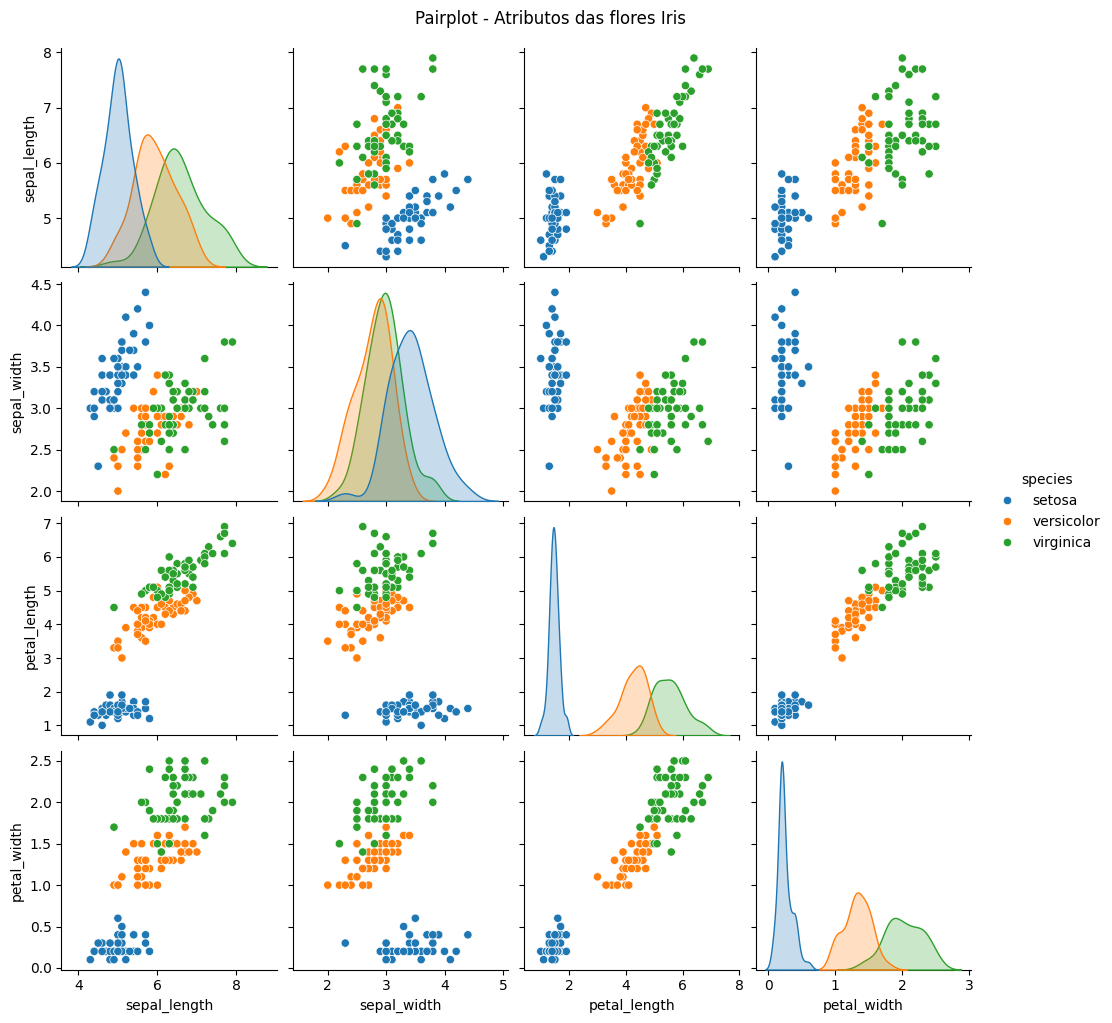

In [21]:
sns.pairplot(iris, hue="species")
plt.suptitle("Pairplot - Atributos das flores Iris", y=1.02)
plt.show()

Teste de Normaldiade de Dados

In [22]:
print("\nTeste de normalidade (Shapiro-Wilk) - Dataset Iris:")
for col in iris_numericas.columns:
    stat, p = shapiro(iris_numericas[col])
    print(f"{col}: stat={stat:.4f}, p={p:.4f}")


Teste de normalidade (Shapiro-Wilk) - Dataset Iris:
sepal_length: stat=0.9761, p=0.0102
sepal_width: stat=0.9849, p=0.1012
petal_length: stat=0.8763, p=0.0000
petal_width: stat=0.9018, p=0.0000


Apenas a variável "sepal_width" tem p-valor > 0,05. Logo apenas ela segue uma distribuição normal

**Correlação de Pearson**

In [23]:
print("\nCorrelação de Pearson - Iris")
corr_pearson = iris_numericas.corr(method='pearson')
corr_pearson


Correlação de Pearson - Iris


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


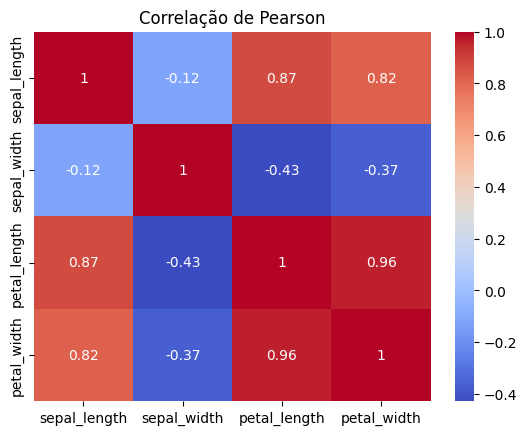

In [24]:
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Correlação de Pearson")
plt.show()

**Correlação de Spearman**

In [25]:
print("\nCorrelação de Spearman - Iris")
corr_spearman = iris_numericas.corr(method='spearman')
corr_spearman


Correlação de Spearman - Iris


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.166778,0.881898,0.834289
sepal_width,-0.166778,1.000000,-0.309635,-0.289032
petal_length,0.881898,-0.309635,1.000000,0.937667
petal_width,0.834289,-0.289032,0.937667,1.000000


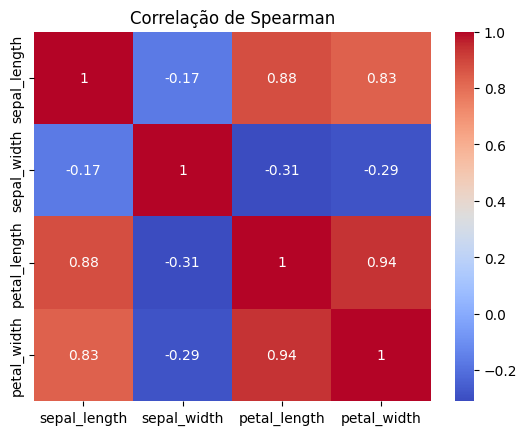

In [26]:
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm")
plt.title("Correlação de Spearman")
plt.show()

**Correlação de Kendall**

In [27]:
corr_kendall = iris_numericas.corr(method='kendall')
corr_kendall

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.076997,0.718516,0.655309
sepal_width,-0.076997,1.000000,-0.185994,-0.157126
petal_length,0.718516,-0.185994,1.000000,0.806891
petal_width,0.655309,-0.157126,0.806891,1.000000


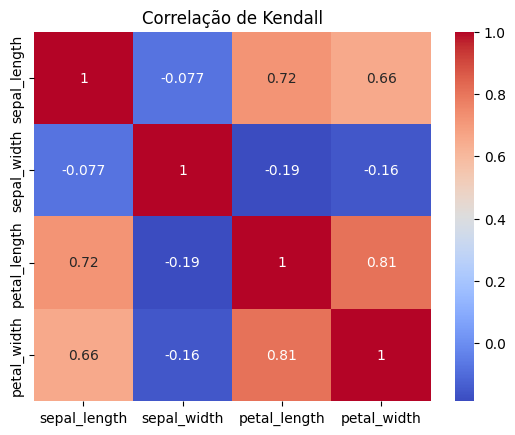

In [28]:
sns.heatmap(corr_kendall, annot=True, cmap="coolwarm")
plt.title("Correlação de Kendall")
plt.show()

**Exercício:**
- Faça o teste de hipótese para a combinação de variáveis 2 a 2.
- analise a direção e força das correlações